### Libraries

In [5]:
import os
import glob
import nibabel as nb
import scipy.stats
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
import numpy as np
import seaborn as sns
import pandas as pd
import cmocean
import matplotlib.pyplot as plt
import matplotlib as mpl
from brainspace.datasets import load_mask

### Variables

In [6]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')
# Load fsLR 32k inflated
f32k_inf_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_inf_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')
mask_32k = load_mask(join=True)

# Boolean mask
#mask_surf = mask_5k != 0
mask_surf = mask_32k != 0

### Functions

In [7]:
# Function: Smooth intensity profiles on a given surface
def smooth_surf(surf_l, surf_r, points, Mask, Kernel='uniform', Niter=3, Relax=0.35):
    '''
    Smooths intensity data on a given surface mesh using iterative smoothing.
    
    Parameters:
    -----------
    surf_l : np.array
        Left hemisphere surface connectivity.
    surf_r : np.array
        Right hemisphere surface connectivity.
    points : np.array
        Intensity profile data mapped to the surface.
    Mask : np.array
        Binary mask indicating valid regions for smoothing.
    Kernel : str, optional
        Smoothing kernel type, options: {'uniform', 'gaussian', 'inverse_distance'}.
    Niter : int, optional
        Number of smoothing iterations (default: 3).
    Relax : float, optional
        Relaxation factor controlling smoothing intensity (default: 0.35).
    
    Returns:
    --------
    sdata : np.array
        Smoothed intensity data.
    '''
    Ndim = Mask.shape[0] 
    n2dim = int(Ndim/2)
    Mask_l = Mask[:n2dim]
    Mask_r = Mask[n2dim:]
    
    sdata = np.concatenate((
        smooth_array(surf_l, points[:n2dim], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_l), 
        smooth_array(surf_r, points[n2dim:], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_r)
    ), axis=0)
    
    return sdata

# Function: Apply smoothing to intensity profiles across all depths
def smooth_intensities(int_profile):
    '''
    Applies surface smoothing to each depth of the intensity profile.
    
    Parameters:
    -----------
    int_profile : np.array
        Input intensity profiles, where rows represent different depths.
    
    Returns:
    --------
    smoothed_i : np.array
        Smoothed intensity profiles.
    '''
    smoothed_i = np.copy(int_profile)
    
    for i in range(int_profile.shape[0]):
        smoothed_i[i, :] = smooth_surf(
            f32k_inf_lh, f32k_inf_rh, int_profile[i, :], mask_surf, Niter=5, Relax=0.5, Kernel='uniform'
        )
    
    return smoothed_i

## AFD - par

In [33]:
lh_par = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/test_initial/csd_singletissue/lh_fsLR32k_afd-par_6mm.txt')
rh_par = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/test_initial/csd_multitissue/rh_fsLR32k_afd-par_6mm.txt')

In [36]:
test_par = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/subjects/PNC003_HC082/L_fsLR32k-FA-test.txt')

ValueError: the number of columns changed from 11 to 7 at row 8; use `usecols` to select a subset and avoid this error

In [24]:
par_0mm = np.concatenate((lh_par[:,7], rh_par[:,7]), axis=0)
par_1mm = np.concatenate((lh_par[:,9], rh_par[:,9]), axis=0)
par_2mm = np.concatenate((lh_par[:,11], rh_par[:,11]), axis=0)
par_SWM = np.vstack([par_0mm, par_1mm, par_2mm])

In [27]:
# Convert -1 to NaN for missing values
par_0mm[par_0mm == -1] = np.nan
par_1mm[par_1mm == -1] = np.nan
par_2mm[par_2mm == -1] = np.nan
par_SWM = np.vstack([par_0mm, par_1mm, par_2mm])

In [28]:
par_smooth = smooth_intensities(par_SWM)
par_smooth[:,mask_32k == False] = np.nan

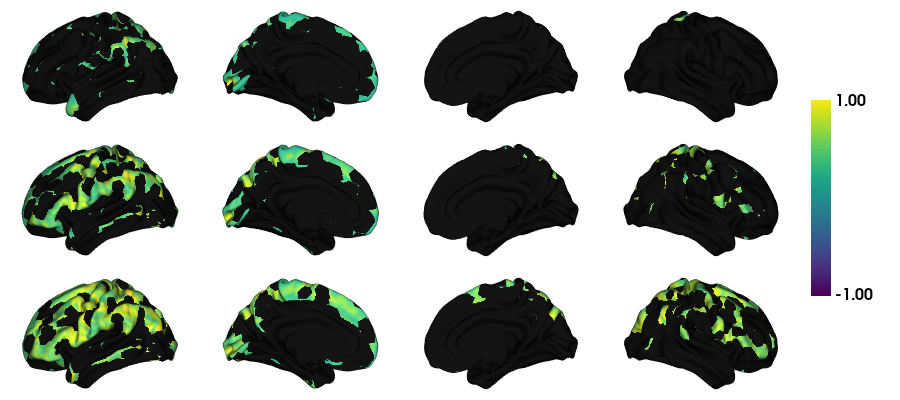

In [29]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=par_smooth, size=(900, 400), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(-1,1))

## AFD -perp

In [16]:
lh_perp = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/test_initial/csd_singletissue/lh_fsLR32k_afd-perp_6mm.txt')
rh_perp = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/test_initial/csd_multitissue/rh_fsLR32k_afd-perp_6mm.txt')

perp_0mm = np.concatenate((lh_perp[:,7], rh_perp[:,7]), axis=0)
perp_1mm = np.concatenate((lh_perp[:,9], rh_perp[:,9]), axis=0)
perp_2mm = np.concatenate((lh_perp[:,11], rh_perp[:,11]), axis=0)
perp_SWM = np.vstack([perp_0mm, perp_1mm, perp_2mm])

perp_smooth = smooth_intensities(perp_SWM)
perp_smooth[:,mask_32k == False] = np.nan

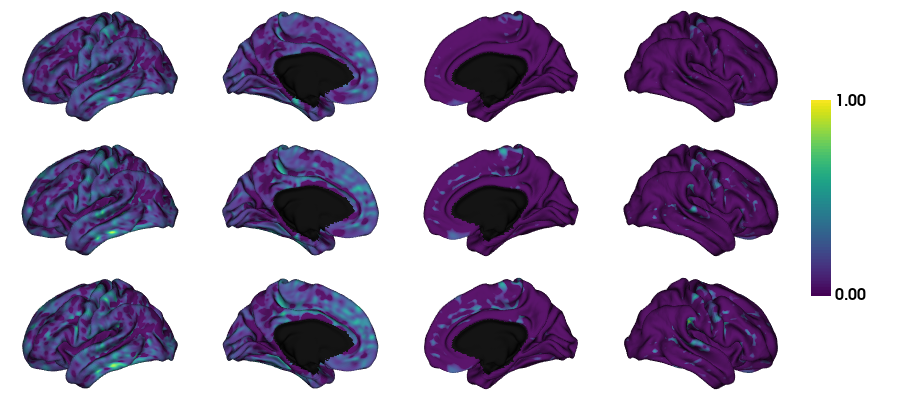

In [20]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=perp_smooth, size=(900, 400), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(0,1))

## AFD - perp-av

In [59]:
lh_perpav = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/test2/csd_singletissue/lh_fsLR32k_afd-perp-av_6mm.txt')
rh_perpav = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/test2/csd_multitissue/rh_fsLR32k_afd-perp-av_6mm.txt')

perpav_0mm = np.concatenate((lh_perpav[:,7], rh_perpav[:,7]), axis=0)
perpav_1mm = np.concatenate((lh_perpav[:,9], rh_perpav[:,9]), axis=0)
perpav_2mm = np.concatenate((lh_perpav[:,11], rh_perpav[:,11]), axis=0)
perpav_SWM = np.vstack([perpav_0mm, perpav_1mm, perpav_2mm])

perpav_smooth = smooth_intensities(perpav_SWM)
perpav_smooth[:,mask_32k == False] = np.nan

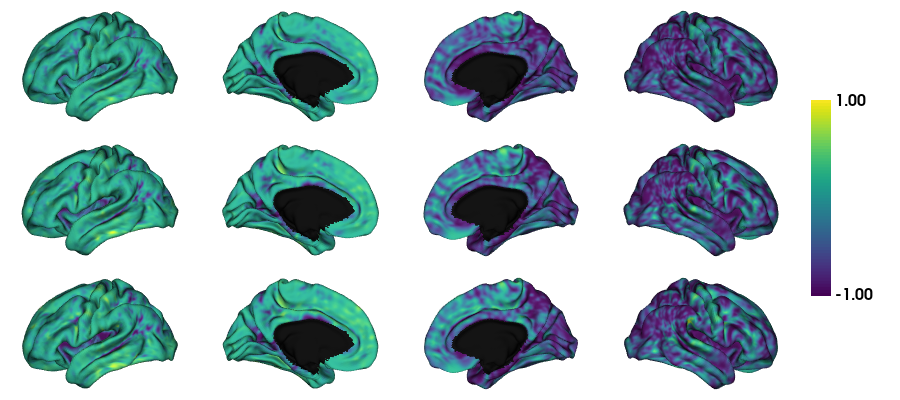

In [60]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=perpav_smooth, size=(900, 400), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(-1,1))

In [38]:
FA = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/test2/lh_fsLR32k-FA.txt')
data_FA = np.concatenate((FA[:,2], FA[:,1]), axis=0)
FA_smooth = smooth_surf(f32k_inf_lh, f32k_inf_rh, data_FA, mask_surf, Niter=5, Relax=0.5, Kernel='uniform')
FA_smooth[mask_32k == False,] = np.nan

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [18]:
parsingleAFD = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/test2/csd_singletissue/lh_fsLR32k_afd-par.txt')
data_parsingleAFD = np.concatenate((parsingleAFD[:,2], parsingleAFD[:,1]), axis=0)
parsingle_smooth = smooth_surf(f32k_inf_lh, f32k_inf_rh, data_parsingleAFD, mask_surf, Niter=5, Relax=0.5, Kernel='uniform')
parsingle_smooth[mask_32k == False,] = np.nan

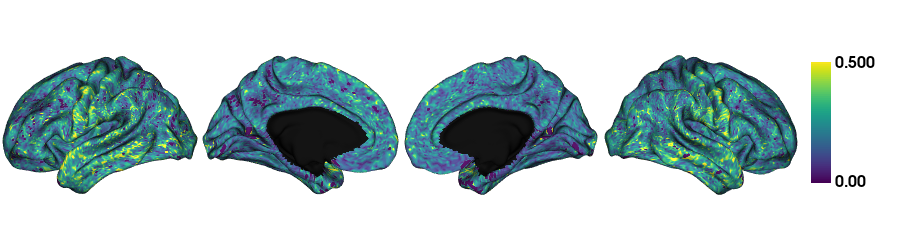

In [13]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=data_parsingleAFD, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(0,0.5))

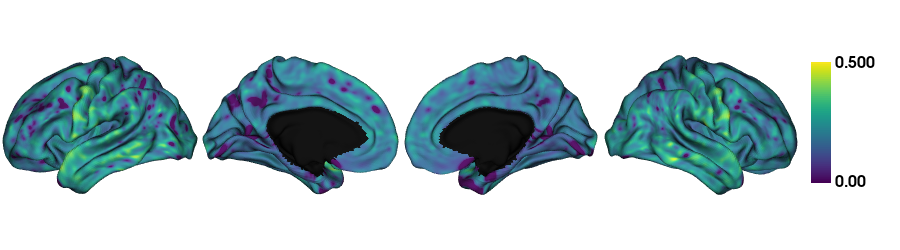

In [19]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=parsingle_smooth, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(0,0.5))

In [6]:
perpsingleAFD = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/test2/csd_singletissue/lh_fsLR32k_afd-perp.txt')
data_perpsingleAFD = np.concatenate((perpsingleAFD[:,4], perpsingleAFD[:,1]), axis=0)
data_perpsingleAFD[mask_32k == False,] = np.nan

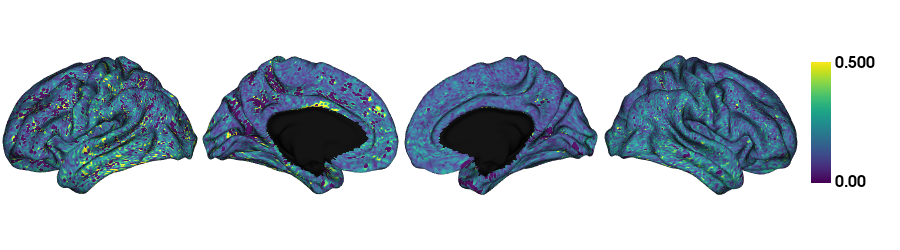

In [10]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=data_perpsingleAFD, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(0,0.5))

In [8]:
perpsingleavAFD = np.loadtxt('/host/verges/tank/data/youngeun/myproject/FBA/test2/csd_singletissue/lh_fsLR32k_afd-perp-av.txt')
data_perpsingleavAFD = np.concatenate((perpsingleavAFD[:,4], perpsingleavAFD[:,1]), axis=0)
data_perpsingleavAFD[mask_32k == False,] = np.nan

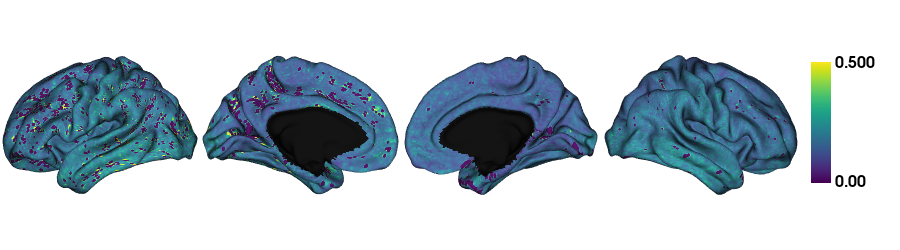

In [11]:
plot_hemispheres(f32k_lh, f32k_rh, array_name=data_perpsingleavAFD, size=(900, 250), color_bar='right', zoom=1.25, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(0,0.5))